## La méthode du gradient pour résoudre A x = b

Le but de ce TP est de vous laisser avancer tout seul. Reprenez les cours et programmez la méthode du gradient
pour résoudre le système matriciel $A {\bf x} = {\bf b}$ avec $A$ symétrique et à diagonale dominante
($a_{ii} > \sum_{k \ne i} |a_{ik}|$).

* Commencez en 2D avec une matrice 2x2, vérifier que le résultat est bon et tracer la courbe de convergence
* Passez en nxn (on montrera que cela marche avec une matrice 9x9)

On va normaliser la matrice $A$ pour éviter que les calculs explosent.

In [1]:
# plein de copier coller du cours

import numpy as np
import numpy.linalg as lin
import matplotlib.pylab as plt
import plotly.offline as py
import plotly.graph_objects as go

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

np.set_printoptions(precision=3, linewidth=150, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use({
    'figure.figsize' : (10,5),
    'axes.titlesize' : 16,
    'axes.labelsize' : 16,
    'lines.linewidth' : 2,
    'lines.markersize' : 8,
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12,
    'image.aspect' : 'equal'
})

### 2x2

Commencez avec une matrice 2x2 pour voir ce qui se passe avant de passer à nxn.

In [2]:
N = 2

A = np.random.randint(-10, 10, size=(N,N))
A = A * 1.0                                            # pour passer en reels
A[np.diag_indices(N)] = 0.1 + np.abs(A).sum(axis=0)    # diag dominante
A = A + A.T                                            # symétriser
A = A / np.abs(A).sum(axis=0).mean()                   # normaliser
b = np.random.randint(-10,10,size=(N))
print(A, "\n\n", b)

[[0.942 0.174]
 [0.174 0.709]] 

 [-2 -1]


In [9]:
def grad_J(x):
    # votre code ici

In [10]:
def minimum_J(start_value, µ=1.2, e = 0.001):
    x = [np.array(start_value)]   # on garde trace des valeurs calculées
    while True:
        # votre code ici
        #
        # la suite n'est que des tests pour se protéger
        if np.square(x[-1] - x[-2]).sum() > 1E9:  # au cas où on diverge
            print("DIVERGE")
            break
        if len(x) > 1000:  # c'est trop long, je crains la boucle infinie
            print('Trop long, boucle infinie ?')
            break
    return np.array(x)

x = minimum_J(np.zeros(N))

In [11]:
A @ x[-1] - b  # tester si c'est la bonne solution

array([0., 0.])

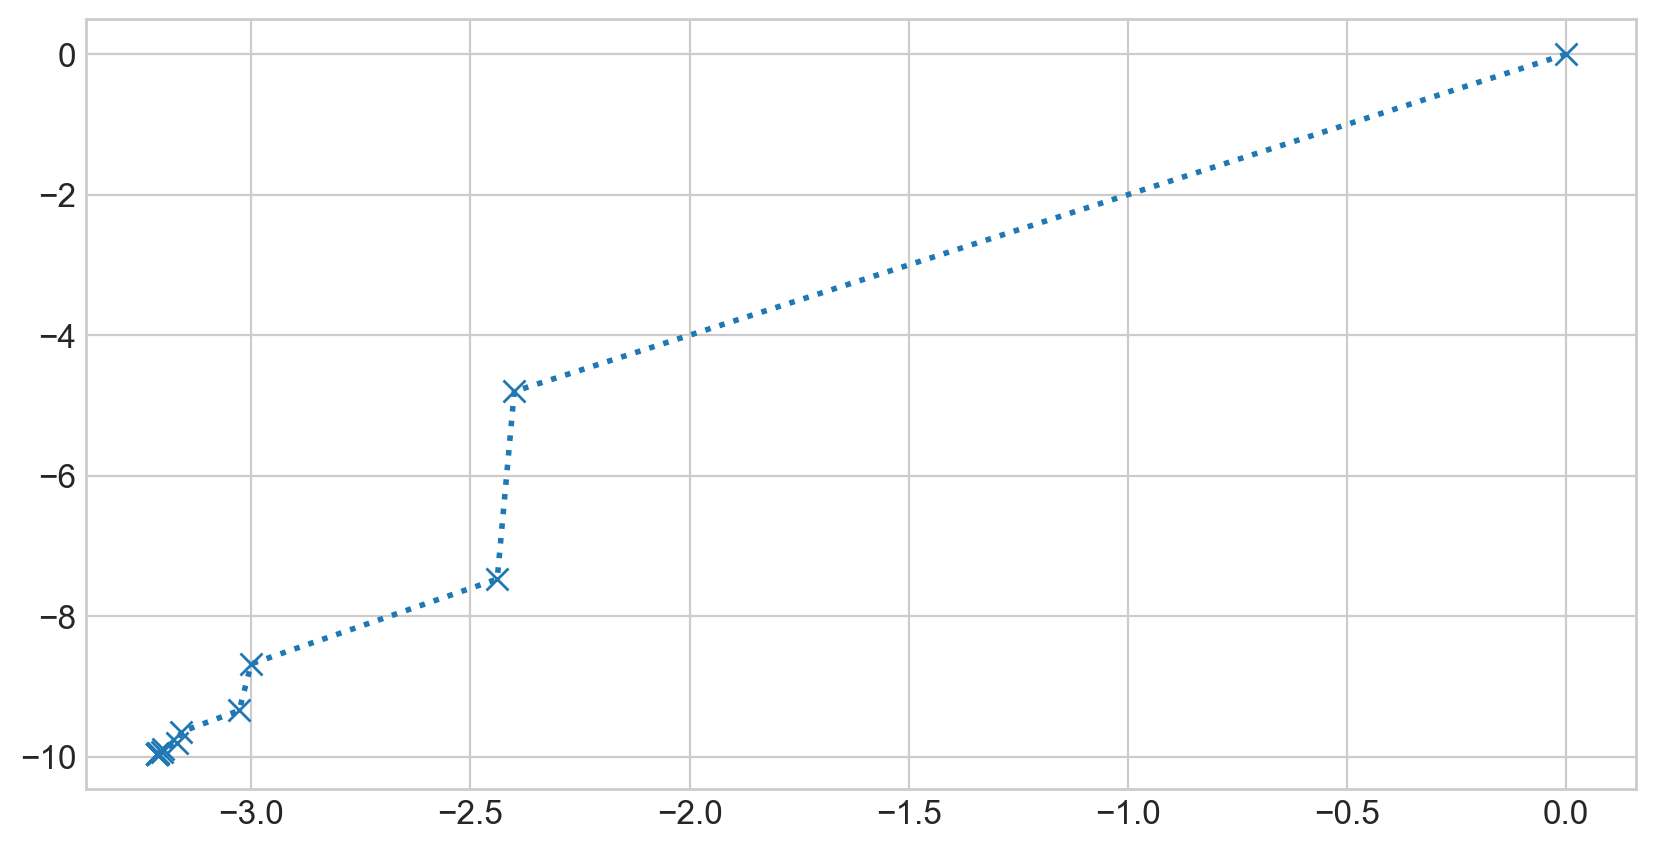

In [12]:
plt.plot(x[:,0], x[:,1], 'x:')   # regarder la convergence

### nxn

Passons à 9x9

In [3]:
N = 9

A = np.random.randint(-10, 10, size=(N,N))
A = A * 1.0                                            # pour passer en reels
A[np.diag_indices(N)] = 0.1 + np.abs(A).sum(axis=0)    # diag dominante
A = A + A.T                                            # symétriser
A = A / np.abs(A).sum(axis=0).mean()                   # normaliser
b = np.random.randint(-10,10,size=(N))

In [14]:
x = minimum_J(np.zeros(N))

In [15]:
A @ x[-1] - b

array([-0.,  0.,  0., -0., -0.,  0., -0., -0., -0.])

In [16]:
print("Converge en %d itérations" % len(x))
x

Converge en 22 itérations


array([[  0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ],
       [  2.4  ,  -6.   ,  -4.8  ,  -4.8  ,   2.4  ,  -1.2  ,  -1.2  , -10.8  ,   0.   ],
       [  4.991,  -9.566,  -7.784,  -5.648,   3.173,  -0.878,  -2.1  , -15.429,  -0.678],
       [  6.132, -11.64 ,  -9.456,  -6.074,   3.87 ,  -0.575,  -2.403, -17.792,  -0.893],
       [  6.754, -12.849, -10.415,  -6.234,   4.298,  -0.313,  -2.467, -18.977,  -0.903],
       [  7.091, -13.562, -10.966,  -6.288,   4.577,  -0.125,  -2.44 , -19.577,  -0.836],
       [  7.279, -13.987, -11.286,  -6.295,   4.756,  -0.001,  -2.387, -19.882,  -0.755],
       [  7.386, -14.244, -11.474,  -6.286,   4.872,   0.077,  -2.336, -20.037,  -0.683],
       [  7.448, -14.401, -11.587,  -6.271,   4.946,   0.124,  -2.294, -20.116,  -0.627],
       [  7.484, -14.498, -11.655,  -6.257,   4.994,   0.152,  -2.262, -20.156,  -0.585],
       [  7.506, -14.559, -11.697,  -6.246,   5.025,   0.167,  -2.238, -20.176,  -0.555],
       [  

## Introduire de l'inertie

Introduire de l'inertie dans la méthode du gradient. Que constate-t-on ?

#### Réponse


## Valeur optimale de µ

On note que deux directions de pente successives sont orthogonales si le point suivant est le minumum dans
la direction donnée ($\nabla J ({\bf x}^k$)).

$$\nabla J ({\bf x}^{k+1})^T \; \nabla J ({\bf x}^k) = 0$$

#### Démonstration 


<table><tr>
    <td>
On veut régler µ pour arriver au minimum de J lorsqu'on avance dans la direction $- \nabla J({\bf x}^{k})$.
Cela veut dire que la dérivée partielle de $J({\bf x}^{k+1})$ par rapport à µ doit être
égale à 0 ou bien en faisant apparaitre µ dans l'équation :

$$
\frac{\partial J ({\bf x}^k - µ \; \nabla J ({\bf x}^k))}{\partial µ} = 0
$$

En développant on a

$$
\begin{align}
\frac{\partial J ({\bf x}^{k+1})}{\partial {\bf x}^{k+1}} \; 
\frac{\partial {\bf x}^{k+1}}{\partial µ} & = 0   \\
J'({\bf x}^{k+1}) \, . \, (- \nabla J ({\bf x}^k)) & = 0 \\
(A\, {\bf x}^{k+1}  - b) \, . \, \nabla J ({\bf x}^k) & = 0 \quad \textrm{puisque $A$ est symétrique}\\
\nabla J ({\bf x}^{k+1})  \, . \, \nabla J ({\bf x}^k) & = 0 \quad \textrm{CQFD}
\end{align}
$$


</td><td>
<img src="images/gradient.png" width = "600px"/>
</td></tr></table>


En utilisant cette propriété, évaluer la valeur optimale de µ pour atteindre le minimum dans la direction de
$\nabla J ({\bf x}^k)$.

#### Réponse


Écrire la méthode du gradient avec le calcul du µ optimal à chaque itération pour résoudre $A {\bf x} = {\bf b}$.

In [17]:
def minimum_J_opt(start_value, e = 0.001):
    x = [np.array(start_value)]   # on garde trace des valeurs calculées
    while True:
        # votre code ici
        #
        # la suite n'est que des tests pour se protéger
        if np.square(x[-1] - x[-2]).sum() > 1E9:  # au cas où on diverge
            print("DIVERGE")
            break
        if len(x) > 1000:  # c'est trop long, je crains la boucle infinie
            print('Trop long, boucle infinie ?')
            break
    return np.array(x)

In [18]:
x = minimum_J_opt(np.zeros(N))
A @ x[-1] - b

array([ 0.,  0.,  0., -0., -0.,  0., -0.,  0., -0.])

In [19]:
print("Converge en %d itérations" % len(x))
x

Converge en 15 itérations


array([[  0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ],
       [  4.464, -11.161,  -8.929,  -8.929,   4.464,  -2.232,  -2.232, -20.09 ,   0.   ],
       [  7.329, -12.691, -10.407,  -6.276,   3.813,  -0.536,  -2.9  , -19.384,  -1.311],
       [  6.932, -14.071, -11.325,  -6.578,   5.041,  -0.115,  -2.46 , -20.209,  -0.879],
       [  7.489, -14.287, -11.542,  -6.286,   4.801,   0.121,  -2.4  , -20.125,  -0.762],
       [  7.429, -14.53 , -11.664,  -6.317,   5.074,   0.152,  -2.256, -20.222,  -0.577],
       [  7.532, -14.582, -11.718,  -6.241,   5.019,   0.19 ,  -2.241, -20.191,  -0.555],
       [  7.515, -14.635, -11.744,  -6.24 ,   5.08 ,   0.182,  -2.204, -20.203,  -0.512],
       [  7.54 , -14.646, -11.756,  -6.222,   5.067,   0.188,  -2.2  , -20.196,  -0.506],
       [  7.536, -14.657, -11.761,  -6.221,   5.081,   0.184,  -2.191, -20.198,  -0.496],
       [  7.541, -14.66 , -11.764,  -6.216,   5.078,   0.185,  -2.19 , -20.196,  -0.495],
       [  